# Feature Engineering
## Attrition Dataset

Se crean nuevas variables a partir de las existentes, con el objetivo de capturar relaciones que los modelos no detectarian directamente. 

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

with open('../data/attrition_dataset.pkl', 'rb') as f:
    df = pd.read_pickle('../data/attrition_dataset.pkl')

df = df.reset_index(drop=True)
target = (df['Attrition'] == 'Yes').astype(int)
print(f'Shape: {df.shape}')

Shape: (1426, 31)


## 1. Indice de Satisfaccion General

El dataset tiene 4 variables de satisfaccion: `JobSatisfaction`, `EnvironmentSatisfaction`, `WorkLifeBalance` e `JobInvolvement`. Cada una captura una dimension del bienestar del empleado. Se propone crear un **indice compuesto** como promedio de las cuatro, para tener una senal mas robusta y reducir el ruido de cada variable individual.

si todas correlacionan negativamente con Attrition, su promedio deberia amplificar esa señal.

Correlacion individual con Attrition:
  JobSatisfaction: -0.169
  EnvironmentSatisfaction: -0.179
  WorkLifeBalance: -0.067
  JobInvolvement: -0.043

Correlacion de satisfaction_index con Attrition: -0.237


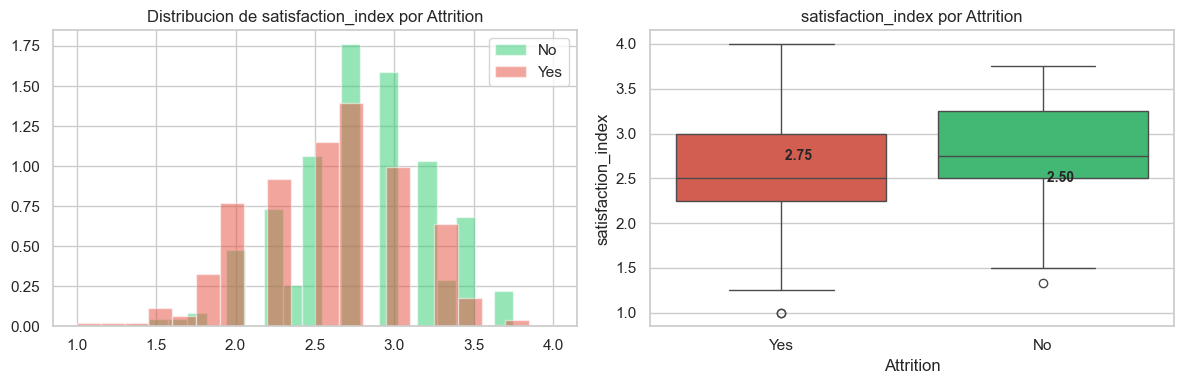

In [14]:
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

print('Correlacion individual con Attrition:')
for col in sat_cols:
    corr = df[col].corr(target)
    print(f'  {col}: {corr:.3f}')

df['satisfaction_index'] = df[sat_cols].mean(axis=1)
corr_new = df['satisfaction_index'].corr(target)
print(f'\nCorrelacion de satisfaction_index con Attrition: {corr_new:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    data = df[df['Attrition'] == label]['satisfaction_index'].dropna()
    axes[0].hist(data, bins=20, alpha=0.5, label=label, color=color, density=True)
axes[0].set_title('Distribucion de satisfaction_index por Attrition')
axes[0].legend()

sns.boxplot(data=df, x='Attrition', y='satisfaction_index', ax=axes[1],
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
axes[1].set_title('satisfaction_index por Attrition')
medians = df.groupby('Attrition')['satisfaction_index'].median()
for j, (label, med) in enumerate(medians.items()):
    axes[1].text(j, med, f' {med:.2f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Ratio de Antiguedad en la Empresa

`YearsAtCompany` y `TotalWorkingYears` por separado no capturan la **lealtad relativa** del empleado. Un empleado con 5 anos en la empresa y 5 anos de experiencia total es muy diferente a uno con 5 anos en la empresa y 20 de experiencia total.

Se crea: `company_tenure_ratio = YearsAtCompany / (TotalWorkingYears + 1)`

Un valor cercano a 1 indica que el empleado ha pasado casi toda su carrera en esta empresa. Un valor bajo indica mayor movilidad laboral.

Correlacion YearsAtCompany con Attrition:       -0.187
Correlacion TotalWorkingYears con Attrition:    -0.234
Correlacion company_tenure_ratio con Attrition: -0.128


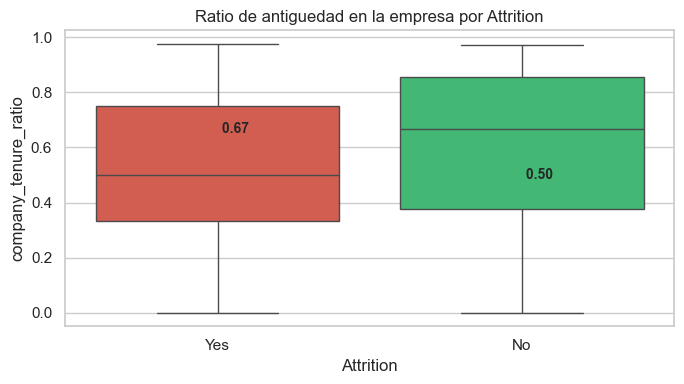

In [15]:
df['company_tenure_ratio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)

corr = df['company_tenure_ratio'].corr(target)
corr_years = df['YearsAtCompany'].corr(target)
corr_total = df['TotalWorkingYears'].corr(target)

print(f'Correlacion YearsAtCompany con Attrition:       {corr_years:.3f}')
print(f'Correlacion TotalWorkingYears con Attrition:    {corr_total:.3f}')
print(f'Correlacion company_tenure_ratio con Attrition: {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Attrition', y='company_tenure_ratio', ax=ax,
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
ax.set_title('Ratio de antiguedad en la empresa por Attrition')
medians = df.groupby('Attrition')['company_tenure_ratio'].median()
for j, (label, med) in enumerate(medians.items()):
    ax.text(j, med, f' {med:.2f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Estancamiento en Promociones

`YearsSinceLastPromotion` en valores absolutos no es tan informativo: 3 anos sin promocion siendo nuevo en la empresa es normal, pero 3 anos sin promocion con 15 anos de antiguedad puede indicar frustracion.

Se crea: `promotion_stagnation = YearsSinceLastPromotion / (YearsAtCompany + 1)`

Un valor alto indica que el empleado lleva mucho tiempo sin ascender en relacion a su tiempo en la empresa.

Correlacion YearsSinceLastPromotion con Attrition: -0.022
Correlacion promotion_stagnation con Attrition:    0.036


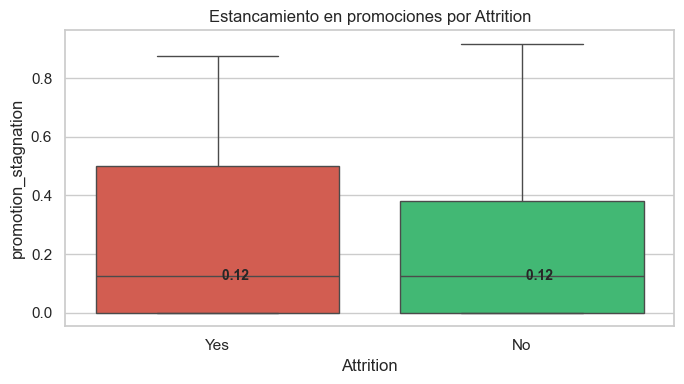

In [16]:
df['promotion_stagnation'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)

corr = df['promotion_stagnation'].corr(target)
corr_orig = df['YearsSinceLastPromotion'].corr(target)

print(f'Correlacion YearsSinceLastPromotion con Attrition: {corr_orig:.3f}')
print(f'Correlacion promotion_stagnation con Attrition:    {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Attrition', y='promotion_stagnation', ax=ax,
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
ax.set_title('Estancamiento en promociones por Attrition')
medians = df.groupby('Attrition')['promotion_stagnation'].median()
for j, (label, med) in enumerate(medians.items()):
    ax.text(j, med, f' {med:.2f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Ingreso Relativo al Nivel del Puesto

Un empleado puede estar bien o mal remunerado **para su nivel jerarquico**. `MonthlyIncome` por si solo no captura si el sueldo es justo en relacion al `JobLevel`.

Se crea: `income_vs_level = (MonthlyIncome - media_del_nivel) / media_del_nivel`

Un valor negativo indica que el empleado gana menos que el promedio de su nivel, lo que podria motivar su salida.

Correlacion MonthlyIncome con Attrition:   -0.050
Correlacion income_vs_level con Attrition: -0.060

Ingreso promedio por JobLevel:
JobLevel
1    60532.0
2    69206.0
3    58011.0
4    65690.0
5    55691.0


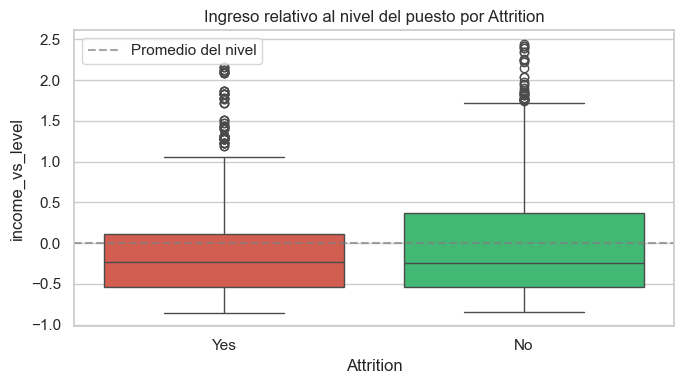

In [17]:
avg_income_by_level = df.groupby('JobLevel')['MonthlyIncome'].transform('mean')
df['income_vs_level'] = (df['MonthlyIncome'] - avg_income_by_level) / avg_income_by_level

corr = df['income_vs_level'].corr(target)
corr_orig = df['MonthlyIncome'].corr(target)

print(f'Correlacion MonthlyIncome con Attrition:   {corr_orig:.3f}')
print(f'Correlacion income_vs_level con Attrition: {corr:.3f}')

print('\nIngreso promedio por JobLevel:')
print(df.groupby('JobLevel')['MonthlyIncome'].mean().round(0).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Attrition', y='income_vs_level', ax=ax,
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
ax.axhline(0, color='gray', linestyle='--', alpha=0.7, label='Promedio del nivel')
ax.set_title('Ingreso relativo al nivel del puesto por Attrition')
ax.legend()
plt.tight_layout()
plt.show()

---

## 6. Estabilidad con el Manager

`YearsWithCurrManager` tiene correlación -0.22 con Attrition, pero en términos absolutos no dice mucho. Un empleado con 3 años con el mismo manager que lleva 3 años en la empresa (100% del tiempo) es muy diferente a uno con 3 años con el mismo manager pero 15 años en la empresa (20% del tiempo).

Se crea: `manager_loyalty_ratio = YearsWithCurrManager / (YearsAtCompany + 1)`

Un valor alto indica que el empleado ha pasado la mayor parte de su tiempo en la empresa bajo el mismo manager, lo que sugiere una relación estable.

Correlacion YearsWithCurrManager con Attrition: -0.217
Correlacion YearsAtCompany con Attrition:       -0.187
Correlacion manager_loyalty_ratio con Attrition: -0.188


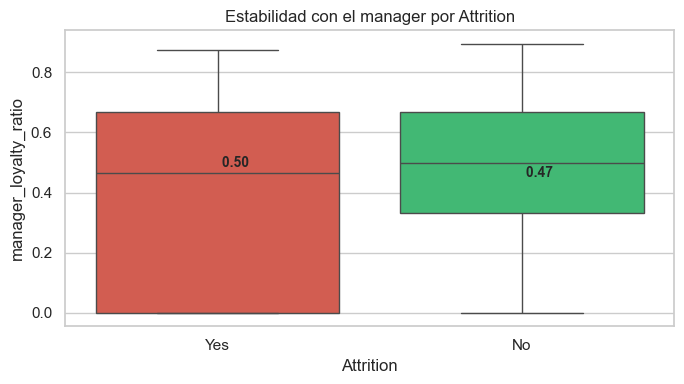

In [18]:
df['manager_loyalty_ratio'] = df['YearsWithCurrManager'] / (df['YearsAtCompany'] + 1)

corr = df['manager_loyalty_ratio'].corr(target)
corr_mgr = df['YearsWithCurrManager'].corr(target)
corr_yac = df['YearsAtCompany'].corr(target)

print(f'Correlacion YearsWithCurrManager con Attrition: {corr_mgr:.3f}')
print(f'Correlacion YearsAtCompany con Attrition:       {corr_yac:.3f}')
print(f'Correlacion manager_loyalty_ratio con Attrition: {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Attrition', y='manager_loyalty_ratio', ax=ax,
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
ax.set_title('Estabilidad con el manager por Attrition')
medians = df.groupby('Attrition')['manager_loyalty_ratio'].median()
for j, (label, med) in enumerate(medians.items()):
    ax.text(j, med, f' {med:.2f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Densidad de Experiencia

`TotalWorkingYears` (-0.25) y `Age` (-0.22) son las dos variables más correlacionadas con Attrition individualmente. Combinarlas en un ratio captura la **madurez profesional relativa**: cuánto de la vida adulta del empleado ha sido experiencia laboral.

Se crea: `experience_density = TotalWorkingYears / (Age - 17)`

Un valor cercano a 1 indica que empezó a trabajar muy joven y lleva mucho tiempo en el mercado laboral. Empleados con mayor densidad de experiencia tienden a ser más estables.

Correlacion TotalWorkingYears con Attrition: -0.234
Correlacion Age con Attrition:               -0.205
Correlacion experience_density con Attrition: -0.173


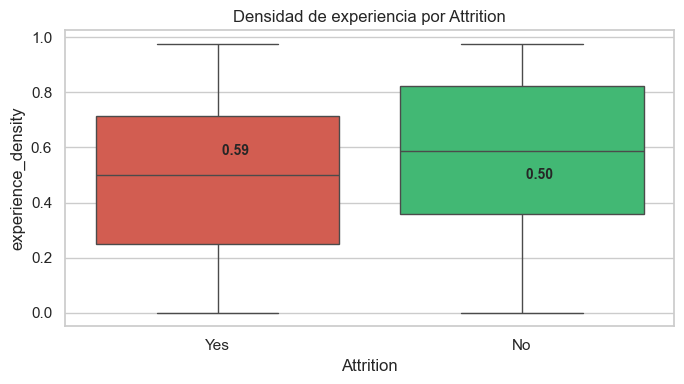

In [19]:
df['experience_density'] = df['TotalWorkingYears'] / (df['Age'] - 17)

corr = df['experience_density'].corr(target)
corr_twy = df['TotalWorkingYears'].corr(target)
corr_age = df['Age'].corr(target)

print(f'Correlacion TotalWorkingYears con Attrition: {corr_twy:.3f}')
print(f'Correlacion Age con Attrition:               {corr_age:.3f}')
print(f'Correlacion experience_density con Attrition: {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Attrition', y='experience_density', ax=ax,
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
ax.set_title('Densidad de experiencia por Attrition')
medians = df.groupby('Attrition')['experience_density'].median()
for j, (label, med) in enumerate(medians.items()):
    ax.text(j, med, f' {med:.2f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Presión de Sobrecarga Laboral

`hrs` tiene correlación +0.21 (más horas → más Attrition) y `WorkLifeBalance` tiene -0.12 (mejor balance → menos Attrition). Juntas capturan el concepto de **burnout**: muchas horas con mal balance de vida.

Se crea: `overwork_pressure = hrs / (WorkLifeBalance + 0.5)`

Un valor alto indica empleados que trabajan mucho y tienen mal balance, perfil de riesgo de desgaste y salida.

Correlacion hrs con Attrition:              0.205
Correlacion WorkLifeBalance con Attrition:  -0.067
Correlacion overwork_pressure con Attrition: 0.179


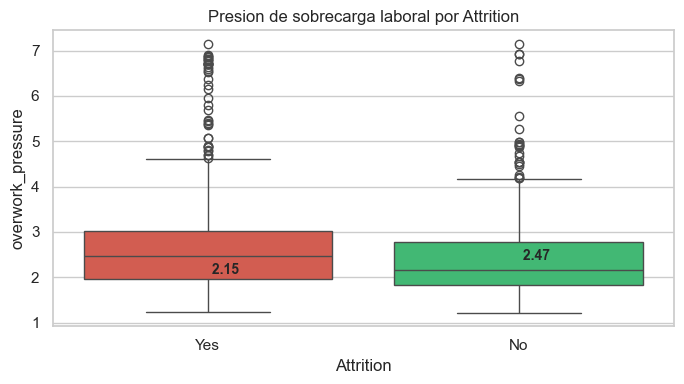

In [20]:
df['overwork_pressure'] = df['hrs'] / (df['WorkLifeBalance'] + 0.5)

corr = df['overwork_pressure'].corr(target)
corr_hrs = df['hrs'].corr(target)
corr_wlb = df['WorkLifeBalance'].corr(target)

print(f'Correlacion hrs con Attrition:              {corr_hrs:.3f}')
print(f'Correlacion WorkLifeBalance con Attrition:  {corr_wlb:.3f}')
print(f'Correlacion overwork_pressure con Attrition: {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Attrition', y='overwork_pressure', ax=ax,
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
ax.set_title('Presion de sobrecarga laboral por Attrition')
medians = df.groupby('Attrition')['overwork_pressure'].median()
for j, (label, med) in enumerate(medians.items()):
    ax.text(j, med, f' {med:.2f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Score de Arraigo a la Empresa

Las variables `YearsAtCompany` (-0.20), `TotalWorkingYears` (-0.25) y `YearsWithCurrManager` (-0.22) capturan distintas dimensiones de cuánto está "arraigado" un empleado. Se propone un score combinado normalizado que integra las tres señales.

Se crea: `anchoring_score = (YearsAtCompany + TotalWorkingYears + YearsWithCurrManager) / 3`

Un valor alto indica un empleado con larga trayectoria, experiencia consolidada y relación estable con su manager — perfil de alta retención.

Correlacion individual con Attrition:
  YearsAtCompany: -0.187
  TotalWorkingYears: -0.234
  YearsWithCurrManager: -0.217

Correlacion anchoring_score con Attrition: -0.241


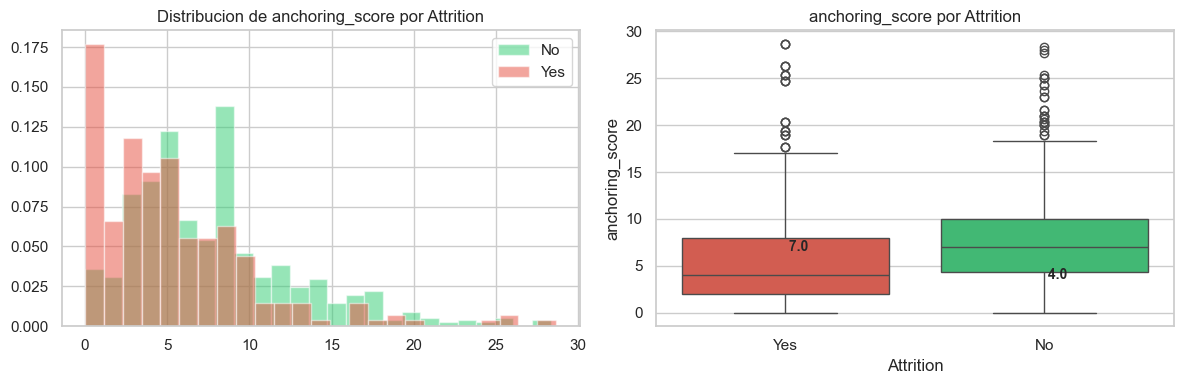

In [21]:
anchor_cols = ['YearsAtCompany', 'TotalWorkingYears', 'YearsWithCurrManager']
df['anchoring_score'] = df[anchor_cols].mean(axis=1)

corr = df['anchoring_score'].corr(target)

print('Correlacion individual con Attrition:')
for col in anchor_cols:
    print(f'  {col}: {df[col].corr(target):.3f}')
print(f'\nCorrelacion anchoring_score con Attrition: {corr:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    data = df[df['Attrition'] == label]['anchoring_score'].dropna()
    axes[0].hist(data, bins=25, alpha=0.5, label=label, color=color, density=True)
axes[0].set_title('Distribucion de anchoring_score por Attrition')
axes[0].legend()

sns.boxplot(data=df, x='Attrition', y='anchoring_score', ax=axes[1],
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
axes[1].set_title('anchoring_score por Attrition')
medians = df.groupby('Attrition')['anchoring_score'].median()
for j, (label, med) in enumerate(medians.items()):
    axes[1].text(j, med, f' {med:.1f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Resumen de Todas las Features Creadas

| Feature | Basada en | Descripcion |
|---|---|---|
| `satisfaction_index` | 4 variables de satisfaccion | Indice compuesto de bienestar general |
| `company_tenure_ratio` | YearsAtCompany, TotalWorkingYears | Proporcion de la carrera en esta empresa |
| `promotion_stagnation` | YearsSinceLastPromotion, YearsAtCompany | Estancamiento relativo en ascensos |
| `income_vs_level` | MonthlyIncome, JobLevel | Sueldo relativo al promedio de su nivel |
| `manager_loyalty_ratio` | YearsWithCurrManager, YearsAtCompany | Estabilidad de la relacion con el manager |
| `experience_density` | TotalWorkingYears, Age | Madurez profesional relativa a la edad |
| `overwork_pressure` | hrs, WorkLifeBalance | Riesgo de burnout por sobrecarga laboral |
| `anchoring_score` | YearsAtCompany, TotalWorkingYears, YearsWithCurrManager | Score de arraigo general a la empresa |

In [1]:
all_features = [
    'satisfaction_index', 'company_tenure_ratio', 'promotion_stagnation', 'income_vs_level',
    'manager_loyalty_ratio', 'experience_density', 'overwork_pressure', 'anchoring_score'
]

print('Correlacion de todas las features con Attrition:')
corrs = {col: df[col].corr(target) for col in all_features}
corrs_series = pd.Series(corrs).sort_values()
print(corrs_series.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corrs_series.values]
ax.barh(corrs_series.index, corrs_series.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlacion con Attrition')
ax.set_title('Correlacion de todas las features engineered con el target')
for i, (val, name) in enumerate(zip(corrs_series.values, corrs_series.index)):
    ax.text(val + (0.002 if val >= 0 else -0.002), i,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

Correlacion de todas las features con Attrition:


NameError: name 'df' is not defined

 Las features con mayor poder predictivo capturan dos dimensiones clave — estabilidad y arraigo (anchoring_score, manager_loyalty_ratio) y bienestar percibido (satisfaction_index, overwork_pressure). Algunas de estas superaron a las variables originales individuales en correlación con el target.